In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/bank/bank-full.csv',sep=';')
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
print(df['y'].value_counts(normalize=True))

(45211, 17)
age          int64
job            str
marital        str
education      str
default        str
balance      int64
housing        str
loan           str
contact        str
day          int64
month          str
duration     int64
campaign     int64
pdays        int64
previous     int64
poutcome       str
y              str
dtype: object
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64
y
no     0.883015
yes    0.116985
Name: proportion, dtype: float64


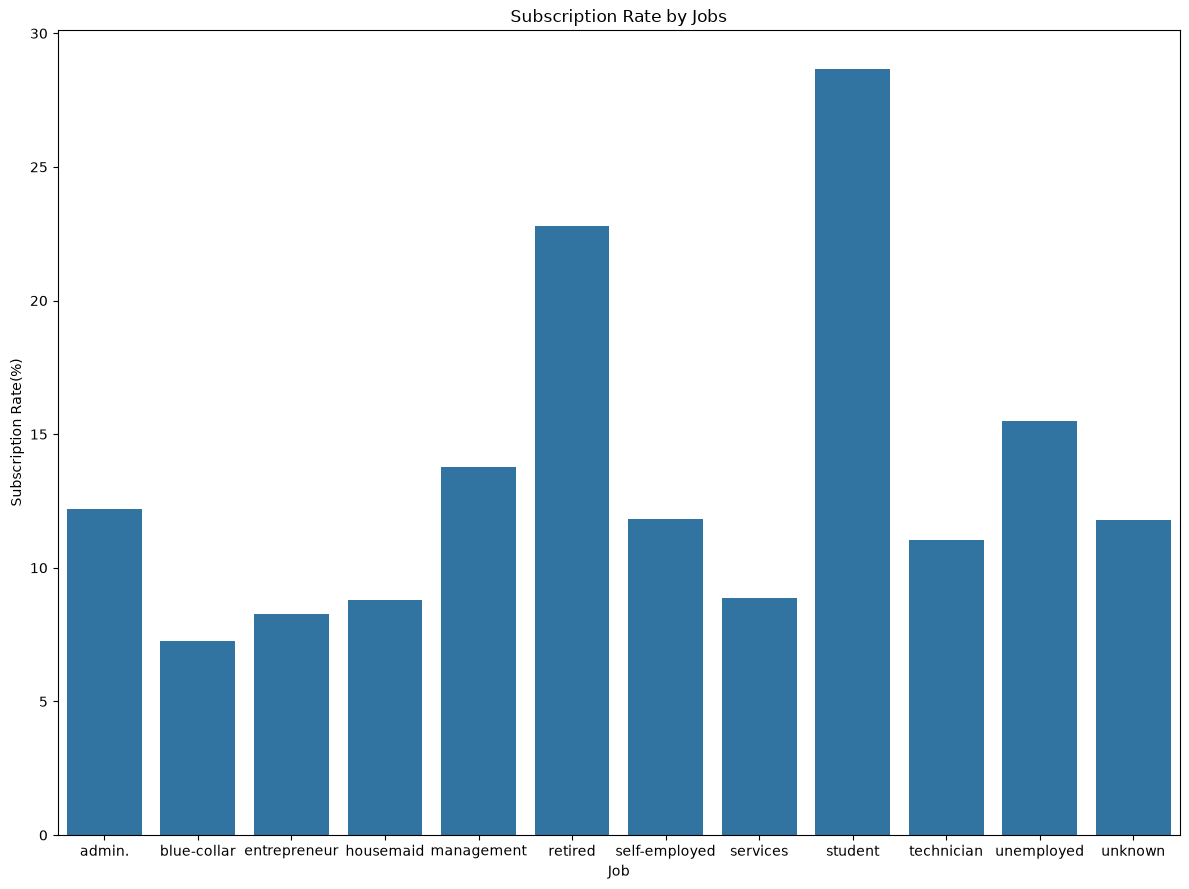

In [51]:
job_sub = df.groupby('job')['y'].apply(lambda x: (x=='yes').mean()*100).reset_index()
job_sub.columns = ['job', 'subscription_rate']
plt.figure(figsize=(12,9))
sns.barplot(x='job',y='subscription_rate',data=job_sub)
plt.title('Subscription Rate by Jobs')
plt.xlabel('Job')
plt.ylabel('Subscription Rate(%)')
plt.tight_layout()
plt.show()

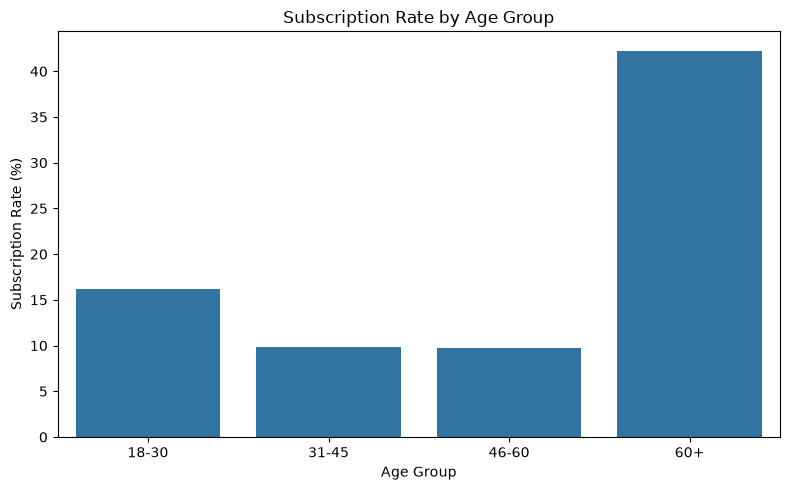

In [ ]:
df['age_group']=  pd.cut(df['age'],bins=[18,30,45,60,100],labels=['18-30','31-45','46-60','60+'])
age_sub = df.groupby('age_group',observed = True)['y'].apply(lambda x: (x=='yes').mean()*100).reset_index()
age_sub.columns = ['age_group', 'subscription_rate']

plt.figure(figsize=(8, 5))
sns.barplot(x='age_group', y='subscription_rate', data=age_sub)
plt.title('Subscription Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Subscription Rate (%)')
plt.tight_layout()
plt.show()

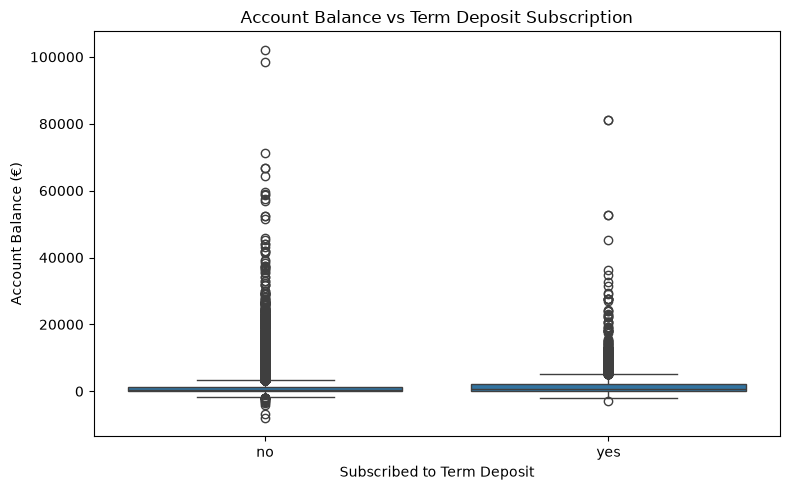

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='y', y='balance', data=df)
plt.title('Account Balance vs Term Deposit Subscription')
plt.xlabel('Subscribed to Term Deposit')
plt.ylabel('Account Balance (€)')
plt.tight_layout()
plt.show()

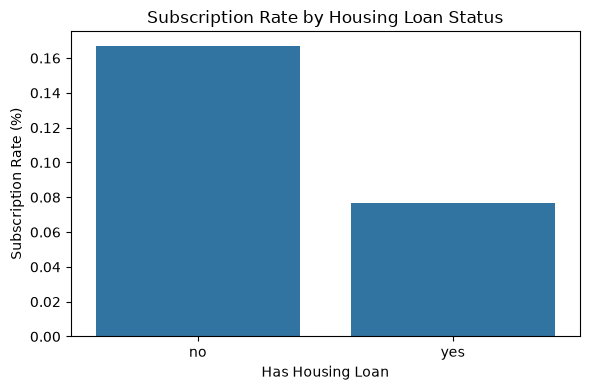

In [57]:
loan_sub = df.groupby('housing')['y'].apply(lambda x: (x=='yes').mean()).reset_index()
loan_sub.columns = ['housing_loan', 'subscription_rate']  # fixed spelling

plt.figure(figsize=(6, 4))
sns.barplot(x='housing_loan', y='subscription_rate', data=loan_sub)
plt.title('Subscription Rate by Housing Loan Status')
plt.xlabel('Has Housing Loan')
plt.ylabel('Subscription Rate (%)')
plt.tight_layout()
plt.show()